# Setup

In [2]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50

In [3]:
print(os.getcwd())

/Users/nawanshaju/Documents/UNSW/26T1/COMP9517/Ass/COMP9517_Project


In [3]:
# GPU Setup

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    
print(device)

mps


In [ ]:
BASE_DIR = "Data/EWS-Dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

In [5]:
IMAGE_SIZE = 350
BATCH_SIZE = 4
EPOCHS = 15
LEARNING_RATE = 1e-4

NUM_CLASSES = 1

In [6]:
from DeepLearning.transformers import make_transforms

train_tf_aug, val_tf = make_transforms(
    augment=True,
    img_size=IMAGE_SIZE
)

train_tf_base, _ = make_transforms(
    augment=False,
    img_size=IMAGE_SIZE
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/nawanshaju/Documents/UNSW/26T1/COMP9517/Ass/COMP9517_Project/DeepLearning/transformers.py:121: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(


In [7]:
from DeepLearning.WheatDataset import WheatDataset

train_dataset_base = WheatDataset(
    TRAIN_DIR,
    transform=train_tf_base
)

train_dataset_aug = WheatDataset(
    TRAIN_DIR,
    transform=train_tf_aug
)

val_dataset = WheatDataset(
    VAL_DIR,
    transform=val_tf
)

test_dataset = WheatDataset(
    TEST_DIR,
    transform=val_tf
)

In [8]:
train_loader_base = torch.utils.data.DataLoader(
    train_dataset_base,
    batch_size=BATCH_SIZE,
    shuffle=True
)

train_loader_aug = torch.utils.data.DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [9]:
def create_model():

    model = deeplabv3_resnet50(
        weights="DEFAULT"
    )
    
    model.classifier[4] = nn.Conv2d(
        256,
        NUM_CLASSES,
        kernel_size=1
    )

    return model.to(device)

In [10]:
from DeepLearning.metrics import evaluate_model

def train_model(
    model,
    train_loader,
    val_loader,
    loss_fn,
    model_name
):

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    best_iou = 0

    train_losses = []
    val_losses = []

    for epoch in range(EPOCHS):

        model.train()

        epoch_loss = 0

        for images, masks in tqdm(train_loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)['out']

            loss = loss_fn(
                outputs,
                masks
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        train_losses.append(epoch_loss)

        val_metrics = evaluate_model(
            model,
            val_loader,
            loss_fn,
            device
        )

        total_loss, precision, recall, f1, iou = val_metrics
        
        val_losses.append(total_loss)

        print(
            f"Epoch {epoch+1}/{EPOCHS}"
        )
        
        print(
            f"Epoch Loss {epoch_loss:.4f}"
        )
        
        print(
            f"Loss {total_loss:.4f}"
        )

        print(
            f"Precision: {precision:.4f}"
        )

        print(
            f"Recall: {recall:.4f}"
        )

        print(
            f"F1: {f1:.4f}"
        )

        print(
            f"IoU: {iou:.4f}"
        )

        if iou > best_iou:

            best_iou = iou

            torch.save(
                model.state_dict(),
                f"{model_name}.pth"
            )

    return train_losses, val_losses

# Base DeepLabV3 Model

In [ ]:
model_base = create_model()

print("Base Model created successfully")

In [25]:
loss_fn_base = nn.BCEWithLogitsLoss()

print("Using BCE Loss as baseline")

Using BCE Loss as baseline


In [ ]:
# base model Training

train_losses_base, val_losses_base = train_model(
    model=model_base,
    train_loader=train_loader_base,
    val_loader=val_loader,
    loss_fn=loss_fn_base,
    model_name="deeplab_base"
)

In [ ]:
# Loads the best model

model_base.load_state_dict(
    torch.load(
        "deeplab_base.pth",
        map_location=device
    )
)

print("Best model loaded\n")

print("Model Info")
print(model_base)


In [ ]:
# Evaluate on test data

test_results = evaluate_model(
    model_base,
    test_loader,
    loss_fn_base,
    device
)

test_loss, precision, recall, f1, iou = test_results

print("BASE MODEL RESULTS\n")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"IoU: {iou:.4f}")

In [ ]:
plt.figure()

plt.plot(
    train_losses_base,
    label="Train Loss"
)

plt.plot(
    val_losses_base,
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [11]:
def visualize_predictions(
    model,
    loader,
    num_samples=3
):

    model.eval()

    with torch.no_grad():

        for images, masks in loader:
            images = images.to(device)
            outputs = model(images)['out']
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()

            for i in range(num_samples):
                img = images[i].cpu().permute(1,2,0)
                mask = masks[i][0]
                pred = preds[i][0].cpu()

                plt.figure(figsize=(12,4))
                plt.subplot(1,3,1)
                plt.title("Image")
                plt.imshow(img)

                plt.subplot(1,3,2)
                plt.title("Ground Truth")
                plt.imshow(mask, cmap='gray')

                plt.subplot(1,3,3)
                plt.title("Prediction")
                plt.imshow(pred, cmap='gray')

                plt.show()

            break


In [ ]:
visualize_predictions(
    model_base,
    test_loader
)

# DeepLabV3 With Data Augmentation

In [12]:
model_aug = create_model()

print("Augmented model created")

Augmented model created


In [13]:
loss_fn_aug = nn.BCEWithLogitsLoss()

In [15]:
train_losses_aug, val_losses_aug = train_model(
    model=model_aug,
    train_loader=train_loader_aug,
    val_loader=val_loader,
    loss_fn=loss_fn_aug,
    model_name="deeplab_augmented"
)

100%|██████████| 36/36 [00:24<00:00,  1.48it/s]


Epoch 1/15
Epoch Loss 16.6355
Loss 4.5956
Precision: 0.9573
Recall: 0.6876
F1: 0.7954
IoU: 0.6689


100%|██████████| 36/36 [00:22<00:00,  1.58it/s]


Epoch 2/15
Epoch Loss 13.0765
Loss 3.1217
Precision: 0.9497
Recall: 0.7915
F1: 0.8614
IoU: 0.7601


100%|██████████| 36/36 [00:22<00:00,  1.59it/s]


...

Epoch 13/15
Epoch Loss 7.3545
Loss 1.3562
Precision: 0.9382
Recall: 0.9235
F1: 0.9306
IoU: 0.8709


100%|██████████| 36/36 [00:22<00:00,  1.59it/s]


Epoch 14/15
Epoch Loss 6.6776
Loss 1.3755
Precision: 0.9417
Recall: 0.9146
F1: 0.9277
IoU: 0.8659


100%|██████████| 36/36 [00:22<00:00,  1.59it/s]


Epoch 15/15
Epoch Loss 6.5052
Loss 1.5561
Precision: 0.9500
Recall: 0.8800
F1: 0.9127
IoU: 0.8406


In [16]:
model_aug.load_state_dict(

    torch.load(
        "deeplab_augmented.pth",
        map_location=device
    )
)

print("Best augmented model loaded")
print(model_aug)

Best augmented model loaded
DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=Tr

In [17]:
test_results_aug = evaluate_model(
    model_aug,
    test_loader,
    loss_fn_aug,
    device
)

test_loss_aug, precision_aug, recall_aug, f1_aug, iou_aug = test_results_aug


print("AUGMENTED MODEL RESULTS\n")

print(f"Precision: {precision_aug:.4f}")
print(f"Recall: {recall_aug:.4f}")
print(f"F1-score: {f1_aug:.4f}")
print(f"IoU: {iou_aug:.4f}")

AUGMENTED MODEL RESULTS

Precision: 0.9365
Recall: 0.9133
F1-score: 0.9247
IoU: 0.8601


In [ ]:
print("MODEL COMPARISON\n")

print("Base Model:")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"IoU: {iou:.4f}")

print("\nAugmented Model:\n")

print(f"Precision: {precision_aug:.4f}")
print(f"Recall: {recall_aug:.4f}")
print(f"F1-score: {f1_aug:.4f}")
print(f"IoU: {iou_aug:.4f}")

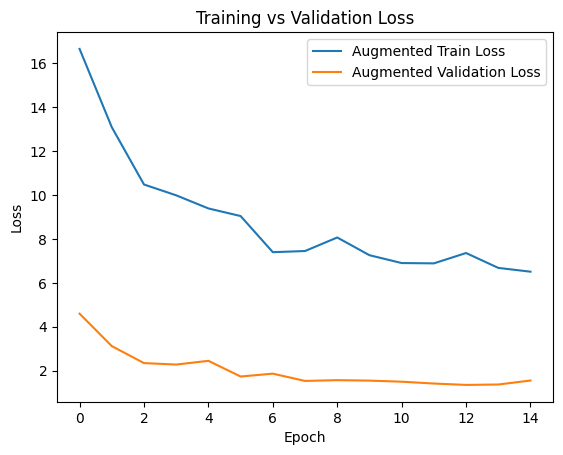

In [18]:
plt.figure()

plt.plot(
    train_losses_aug,
    label="Augmented Train Loss"
)

plt.plot(
    val_losses_aug,
    label="Augmented Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285712].


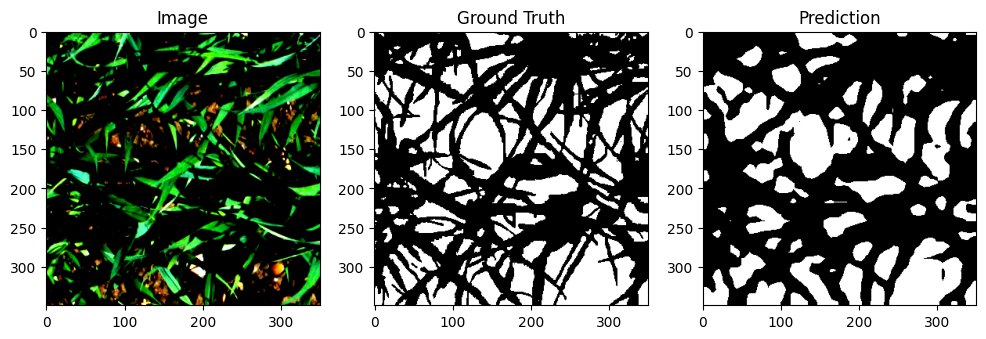

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].


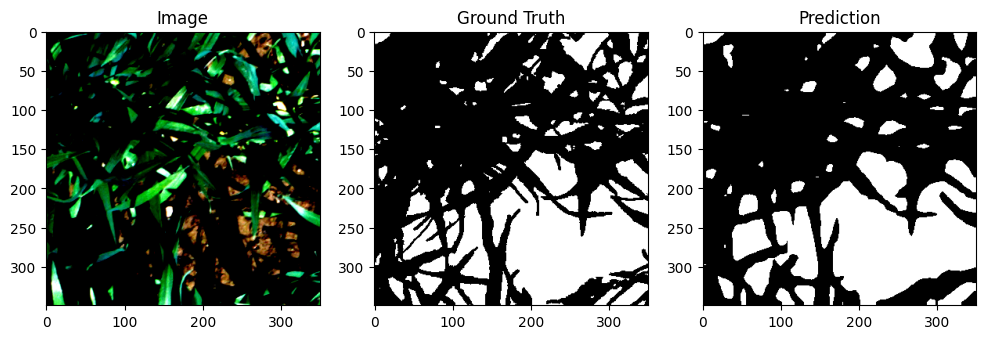

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.6399999].


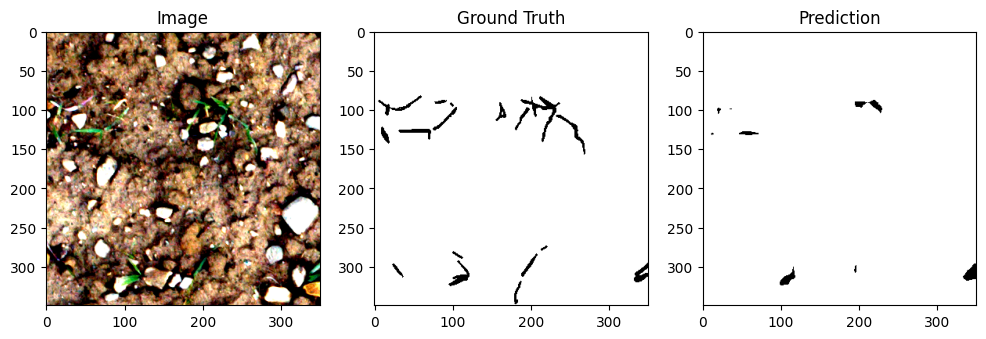

In [19]:
visualize_predictions(
    model_aug,
    test_loader
)

# DeepLabV3 With Original Image + Data Augmentation

In [26]:
from torch.utils.data import ConcatDataset

train_dataset_combined = ConcatDataset([
    train_dataset_base,
    train_dataset_aug
])

In [27]:
train_loader_combined = torch.utils.data.DataLoader(
    train_dataset_combined,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [28]:
model_combined = create_model()

print("Combined model created")

Combined model created


In [29]:
train_losses_comb, val_losses_comb = train_model(
    model=model_combined,
    train_loader=train_loader_combined,
    val_loader=val_loader,
    loss_fn=loss_fn_base,
    model_name="deeplab_combined"
)

100%|██████████| 71/71 [00:45<00:00,  1.55it/s]


Epoch 1/15
Epoch Loss 33.4050
Loss 2.2796
Precision: 0.8392
Recall: 0.9335
F1: 0.8837
IoU: 0.7934


100%|██████████| 71/71 [00:45<00:00,  1.57it/s]


Epoch 2/15
Epoch Loss 22.6284
Loss 1.9286
Precision: 0.9451
Recall: 0.8516
F1: 0.8955
IoU: 0.8122


100%|██████████| 71/71 [00:45<00:00,  1.58it/s]


...

Epoch 13/15
Epoch Loss 12.1789
Loss 1.2556
Precision: 0.9214
Recall: 0.9479
F1: 0.9344
IoU: 0.8774


100%|██████████| 71/71 [00:47<00:00,  1.48it/s]


Epoch 14/15
Epoch Loss 12.7908
Loss 1.2855
Precision: 0.9392
Recall: 0.9300
F1: 0.9342
IoU: 0.8771


100%|██████████| 71/71 [00:44<00:00,  1.58it/s]


Epoch 15/15
Epoch Loss 11.9453
Loss 2.6751
Precision: 0.8375
Recall: 0.9698
F1: 0.8959
IoU: 0.8142


In [30]:
model_combined.load_state_dict(

    torch.load(
        "deeplab_combined.pth",
        map_location=device
    )
)

print("Best augmented model loaded")
print(model_combined)

Best augmented model loaded
DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=Tr

In [31]:
test_results_comb = evaluate_model(
    model_combined,
    test_loader,
    loss_fn_base,
    device
)

test_loss_comb, precision_comb, recall_comb, f1_comb, iou_comb = test_results_comb


print("COMBINED MODEL RESULTS\n")

print(f"Precision: {precision_comb:.4f}")
print(f"Recall: {recall_comb:.4f}")
print(f"F1-score: {f1_comb:.4f}")
print(f"IoU: {iou_comb:.4f}")

COMBINED MODEL RESULTS

Precision: 0.9411
Recall: 0.9190
F1-score: 0.9298
IoU: 0.8690


In [ ]:
print("MODEL COMPARISON\n")

print("Base Model:\n")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"IoU: {iou:.4f}")

print("\nAugmented Model:\n")

print(f"Precision: {precision_aug:.4f}")
print(f"Recall: {recall_aug:.4f}")
print(f"F1-score: {f1_aug:.4f}")
print(f"IoU: {iou_aug:.4f}")

print("\nCombined MODEL\n")

print(f"Precision: {precision_comb:.4f}")
print(f"Recall: {recall_comb:.4f}")
print(f"F1-score: {f1_comb:.4f}")
print(f"IoU: {iou_comb:.4f}")

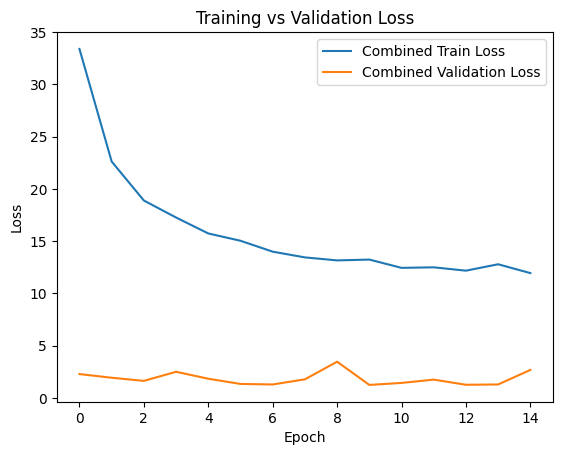

In [32]:
plt.figure()

plt.plot(
    train_losses_comb,
    label="Combined Train Loss"
)

plt.plot(
    val_losses_comb,
    label="Combined Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285712].


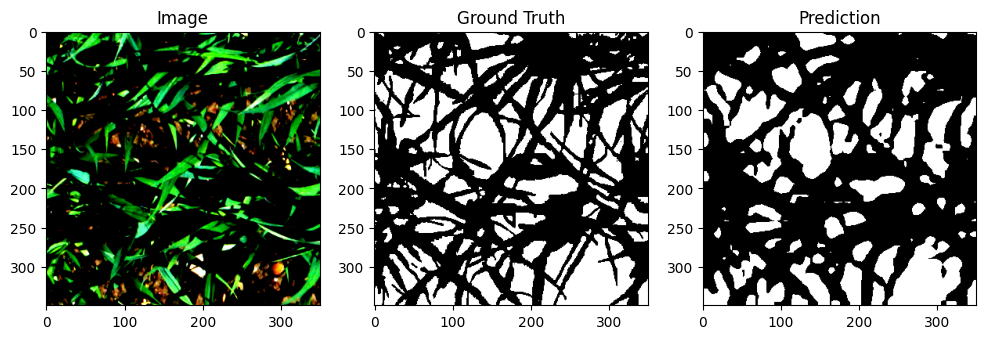

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].


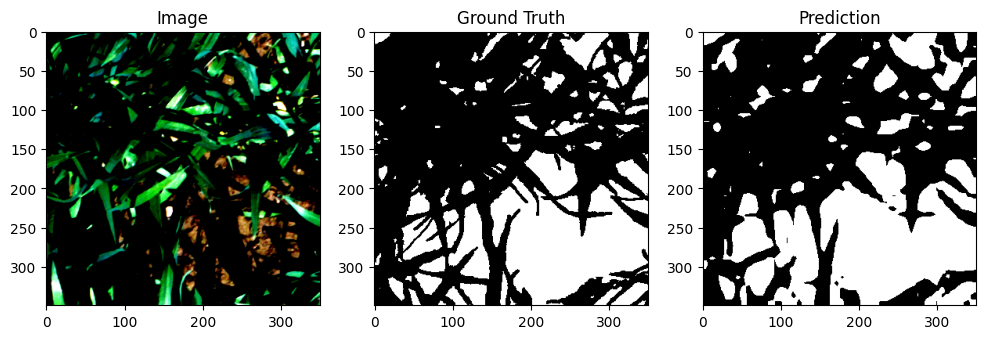

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.6399999].


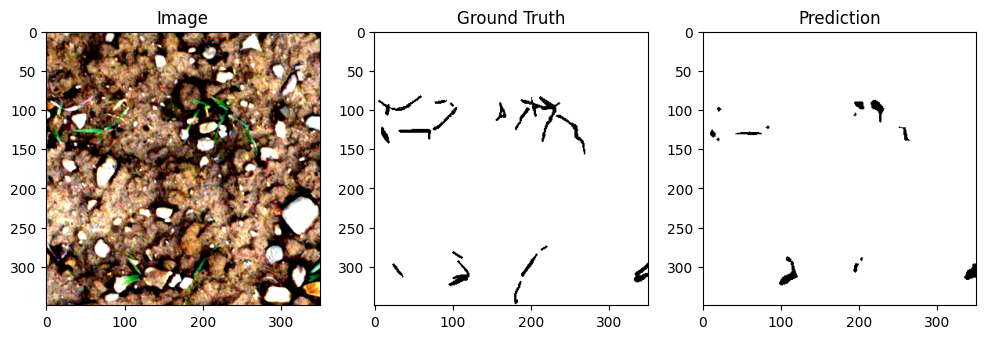

In [33]:
visualize_predictions(
    model_combined,
    test_loader
)

## Testing with augmented test data

In [34]:
test_dataset_aug = WheatDataset(
    TEST_DIR,
    transform=train_tf_aug
)

test_loader_aug = torch.utils.data.DataLoader(
    test_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
print("BASE MODEL → AUGMENTED TEST")

base_aug_results = evaluate_model(
    model_base,
    test_loader_aug,
    loss_fn_base,
    device
)

print("\nBase Model on Augmented Test:")

print(f"Precision: {base_aug_results[1]:.4f}")
print(f"Recall: {base_aug_results[2]:.4f}")
print(f"F1-score: {base_aug_results[3]:.4f}")
print(f"IoU: {base_aug_results[4]:.4f}")

In [ ]:
print("\nAUGMENTED MODEL → AUGMENTED TEST")

aug_aug_results = evaluate_model(
    model_aug,
    test_loader_aug,
    loss_fn_base,
    device
)

print("\nAugmented Model on Augmented Test:")

print(f"Precision: {aug_aug_results[1]:.4f}")
print(f"Recall: {aug_aug_results[2]:.4f}")
print(f"F1-score: {aug_aug_results[3]:.4f}")
print(f"IoU: {aug_aug_results[4]:.4f}")

In [35]:
print("\nCOMBINED MODEL → AUGMENTED TEST")

comb_aug_results = evaluate_model(
    model_combined,
    test_loader_aug,
    loss_fn_base,
    device
)

print("\nAugmented Model on Augmented Test:")

print(f"Precision: {comb_aug_results[1]:.4f}")
print(f"Recall: {comb_aug_results[2]:.4f}")
print(f"F1-score: {comb_aug_results[3]:.4f}")
print(f"IoU: {comb_aug_results[4]:.4f}")


COMBINED MODEL → AUGMENTED TEST

Augmented Model on Augmented Test:
Precision: 0.9019
Recall: 0.9487
F1-score: 0.9244
IoU: 0.8601


In [36]:
DISPLAY_INDICES = [0, 10, 20]

imgs_list  = []
masks_list = []
for idx in DISPLAY_INDICES:
    img, mask = test_loader_aug.dataset[idx]
    imgs_list.append(img)
    masks_list.append(mask)

fixed_loader = [(torch.stack(imgs_list), torch.stack(masks_list))]

In [ ]:
print("Base Model Predictions on Augmented Test\n\n")

visualize_predictions(
    model_base,
    fixed_loader,
)

print("Augmented Model Predictions on Augmented Test\n\n")

visualize_predictions(
    model_aug,
    fixed_loader,
)



Base Model Predictions on Augmented Test




NameError: name 'model_base' is not defined

Combined Model Predictions on Augmented Test




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.4285712].


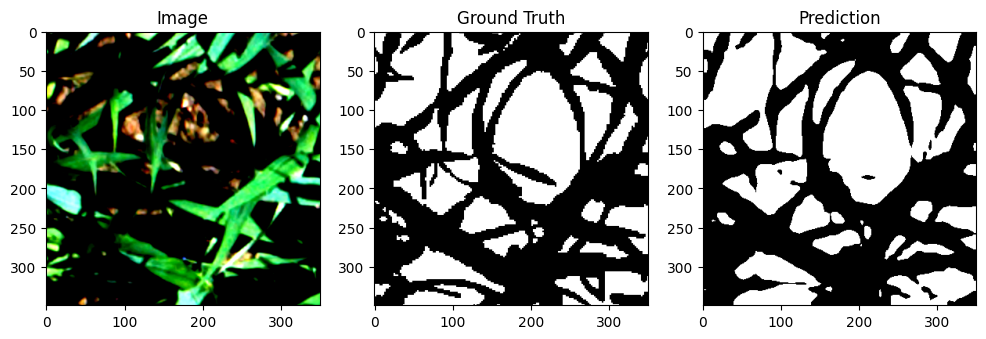

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..0.9303022].


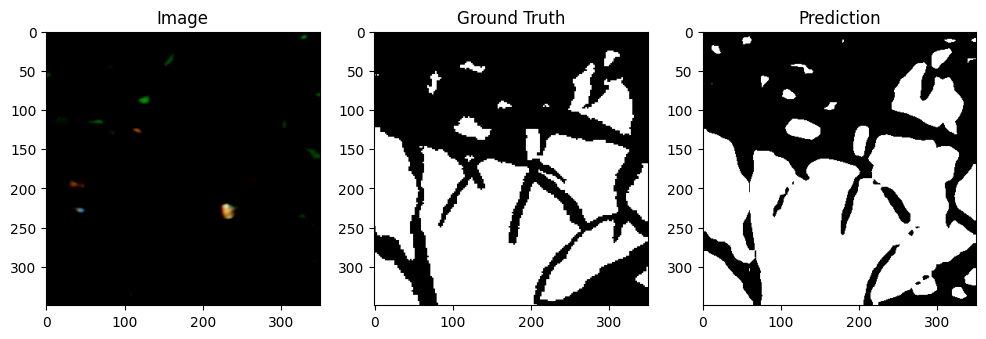

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.415789..2.3410363].


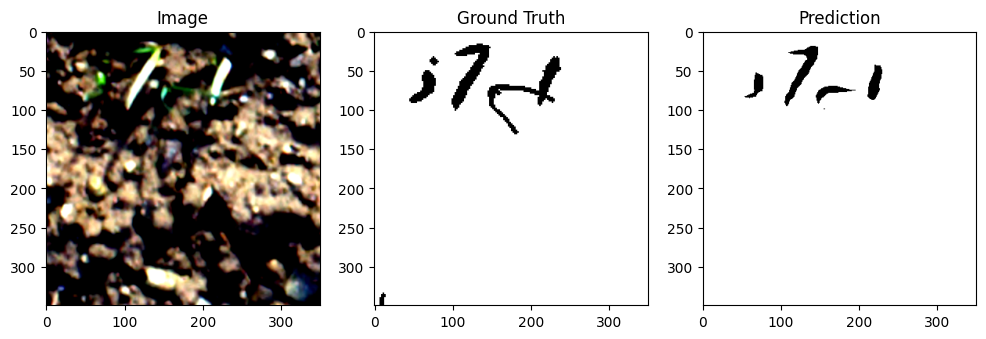

In [38]:
print("Combined Model Predictions on Augmented Test\n\n")

visualize_predictions(
    model_combined,
    fixed_loader,
)

In [ ]:
plt.figure()

plt.plot(
    train_losses_base,
    label="Base Train Loss"
)

plt.plot(
    train_losses_aug,
    label="Augmented Train Loss"
)

plt.plot(
    train_losses_comb,
    label="Combined Train Loss",
    color='red'
)

plt.title("Base vs Augmented vs Combined Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# DeepLabV3 With Different Loss Functions

In [ ]:
from DeepLearning.loss_functions import (
    BCELoss,
    DiceLoss,
    BCEDiceLoss,
    FocalLoss
)

In [ ]:
from torch.utils.data import ConcatDataset

train_dataset_combined = ConcatDataset([
    train_dataset_base,
    train_dataset_aug
])

In [ ]:
train_loader_combined = torch.utils.data.DataLoader(
    train_dataset_combined,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [ ]:
model_bce = create_model()
loss_bce = BCELoss()

train_losses_bce, val_losses_bce = train_model(
    model=model_bce,
    train_loader=train_loader_combined,
    val_loader=val_loader,
    loss_fn=loss_bce,
    model_name="deeplab_bce"
)

In [ ]:
model_dice = create_model()
loss_dice = DiceLoss()

train_losses_dice, val_losses_dice = train_model(
    model=model_dice,
    train_loader=train_loader_combined,
    val_loader=val_loader,
    loss_fn=loss_dice,
    model_name="deeplab_dice"
)

In [ ]:
model_bce_dice = create_model()
loss_bce_dice = BCEDiceLoss()

train_losses_bce_dice, val_losses_bce_dice = train_model(
    model=model_bce_dice,
    train_loader=train_loader_combined,
    val_loader=val_loader,
    loss_fn=loss_bce_dice,
    model_name="deeplab_bce_dice"
)

In [ ]:
model_focal = create_model()
loss_focal = FocalLoss()

train_losses_focal, val_losses_focal = train_model(
    model=model_focal,
    train_loader=train_loader_combined,
    val_loader=val_loader,
    loss_fn=loss_focal,
    model_name="deeplab_focal"
)

In [ ]:
model_bce = create_model()
model_bce.load_state_dict(torch.load('deeplab_bce.pth'))
loss_bce = BCELoss()

model_dice = create_model()
model_dice.load_state_dict(torch.load('deeplab_dice.pth'))
loss_dice = DiceLoss()

model_bce_dice = create_model()
model_bce_dice.load_state_dict(torch.load('deeplab_bce_dice.pth'))
loss_bce_dice = BCEDiceLoss()

model_focal = create_model()
model_focal.load_state_dict(torch.load('deeplab_focal.pth'))
loss_focal = FocalLoss()

In [ ]:
results = {}

results["BCE"] = evaluate_model(
    model_bce,
    test_loader,
    loss_bce,
    device
)

results["Dice"] = evaluate_model(
    model_dice,
    test_loader,
    loss_dice,
    device
)

results["BCE+Dice"] = evaluate_model(
    model_bce_dice,
    test_loader,
    loss_bce_dice,
    device
)

results["Focal"] = evaluate_model(
    model_focal,
    test_loader,
    loss_focal,
    device
)

In [ ]:
print("\nLOSS FUNCTION COMPARISON\n")

for name, res in results.items():

    print(name)

    print(f"Precision: {res[1]:.4f}")

    print(f"Recall: {res[2]:.4f}")

    print(f"F1-score: {res[3]:.4f}")

    print(f"IoU: {res[4]:.4f}")

    print()

# Training With Different Dataset Size

In [4]:
from DeepLearning.loss_functions import FocalLoss

In [ ]:
from torch.utils.data import ConcatDataset

train_dataset_combined = ConcatDataset([
    train_dataset_base,
    train_dataset_aug
])

In [ ]:
from torch.utils.data import DataLoader

train_loader_combined = DataLoader(
    train_dataset_combined,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [ ]:
import torch
from torch.utils.data import Subset
import numpy as np

dataset_sizes = [0.25, 0.50, 0.75, 1.0]

subset_datasets = {}

total_size = len(train_dataset_combined)

indices = np.random.permutation(total_size)

for size in dataset_sizes:

    subset_size = int(total_size * size)

    subset_indices = indices[:subset_size]

    subset_datasets[size] = Subset(
        train_dataset_combined,
        subset_indices
    )

    print(f"{int(size*100)}% dataset size:",
          len(subset_datasets[size]))

In [ ]:
subset_loaders = {}

for size in dataset_sizes:

    subset_loaders[size] = DataLoader(
        subset_datasets[size],
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

In [ ]:
dataset_results = {}
loss_focal = FocalLoss()

for size in dataset_sizes:

    print("\n========================")
    print(f"Training with {int(size*100)}% dataset")
    print("========================")

    model = create_model()

    train_loader = subset_loaders[size]

    train_losses_size, val_losses_size = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_focal,
        model_name=f"deeplab_dataset_{int(size*100)}"
    )

    metrics = evaluate_model(
        model,
        val_loader,
        loss_focal,
        device
    )

    dataset_results[size] = (metrics, train_losses_size, val_losses_size)

In [ ]:
print("\nDATASET SIZE RESULTS")

for size in dataset_sizes:

    metrics, _, _ = dataset_results[size]
    
    total_loss, precision, recall, f1, iou = metrics

    print(f"\n{int(size*100)}% Dataset:")
    print(f"Total Loss: {total_loss:.4f}")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1-score:   {f1:.4f}")
    print(f"IoU:        {iou:.4f}")

In [ ]:
import matplotlib.pyplot as plt

sizes = []
ious = []

for size in dataset_sizes:

    metrics, _, _ = dataset_results[size]
    
    total_loss, precision, recall, f1, iou = metrics

    sizes.append(int(size * 100))
    ious.append(iou)

plt.figure()

plt.plot(sizes, ious, marker='o')

plt.xlabel("Dataset Size (%)")
plt.ylabel("IoU")
plt.title("IoU vs Dataset Size")

plt.grid()

plt.show()